Sensitivity matrix:
[[0.248 0.245 0.264 0.321 0.21  0.198]
 [0.251 0.248 0.267 0.325 0.213 0.2  ]
 [0.223 0.22  0.237 0.288 0.189 0.177]
 [0.131 0.13  0.14  0.17  0.111 0.104]
 [0.079 0.078 0.084 0.103 0.067 0.063]
 [0.037 0.036 0.039 0.047 0.031 0.029]]

Elasticity matrix:
[[0.    0.011 0.068 0.103 0.038 0.029]
 [0.248 0.    0.    0.    0.    0.   ]
 [0.    0.237 0.    0.    0.    0.   ]
 [0.    0.    0.17  0.    0.    0.   ]
 [0.    0.    0.    0.067 0.    0.   ]
 [0.    0.    0.    0.    0.029 0.   ]]


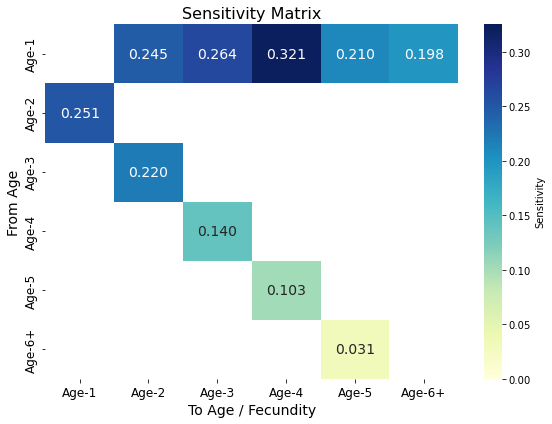

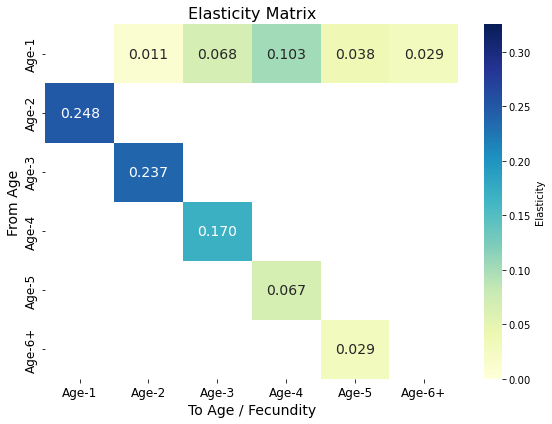

In [27]:
import numpy as np
from scipy.linalg import eig
import seaborn as sns
import matplotlib.pyplot as plt

# Define Leslie matrix L
L = np.array([
    [0, 0.036, 0.204, 0.255, 0.144, 0.118],
    [0.789, 0, 0, 0, 0, 0],
    [0, 0.860, 0, 0, 0, 0],
    [0, 0, 0.971, 0, 0, 0],
    [0, 0, 0, 0.523, 0, 0],
    [0, 0, 0, 0, 0.750, 0.]
])

# Compute dominant eigenvalue and right eigenvector
eigvals, right_vecs = eig(L) 
dominant_index = np.argmax(np.abs(eigvals)) # index of largest eigenvalue
lambda1 = eigvals[dominant_index].real      # dominant eigenvalue (lambda)
w = right_vecs[:, dominant_index].real      # corresponding right eigenvector
w = w / np.sum(w)                           # normalized right eigenvector (SAD)

# Left eigenvector
eigvals_left, left_vecs = eig(L.T)          # eigenvectors of L transpose
v = left_vecs[:, dominant_index].real       # select left eigenvector
v = v / (v @ w)                             # normalized so <v, w> = 1

sensitivity = np.outer(v, w)                # s_ij = v_i * w_j
elasticity = (L / lambda1) * sensitivity    # e_ij = (a_ij / lambda) * s_ij

# Display results 
print("Sensitivity matrix:")
print(np.round(sensitivity, 3))
print("\nElasticity matrix:")
print(np.round(elasticity, 3))

# Age labels for axes
ages = ["Age-1", "Age-2", "Age-3", "Age-4", "Age-5", "Age-6+"]

# Create a mask for biologically meaningful entries
# True = hide, False = show
# Meaningful entries:
# - Fecundity: first row, columns 2-6
# - Survival: subdiagonal (row i+1, col i)
mask = np.ones_like(sensitivity, dtype=bool)
mask[0, 1:6] = False
for i in range(1, 6):
    mask[i, i-1] = False

# Determine common max value for color scaling
# Ensures sensitivity and elasticity use the same color scale
max_val = max(sensitivity.max(), elasticity.max())


# Sensitivity heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    sensitivity,
    mask=mask,
    annot=True,                # Show values inside cells
    fmt=".3f",                 # 3 decimal places
    cmap="YlGnBu",
    xticklabels=ages,
    yticklabels=ages,
    vmin=0,
    vmax=max_val,              # Same scale for both matrices
    cbar_kws={'label': 'Sensitivity'},
    annot_kws={"size": 14}     # Font size for numbers
)
plt.title("Sensitivity Matrix", fontsize=16)
plt.xlabel("To Age / Fecundity", fontsize=14)
plt.ylabel("From Age", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig("sensitivity_matrix.jpg", dpi=300)
plt.show()

# Elasticity heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    elasticity,
    mask=mask,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    xticklabels=ages,
    yticklabels=ages,
    vmin=0,
    vmax=max_val,              # Same scale as sensitivity
    cbar_kws={'label': 'Elasticity'},
    annot_kws={"size": 14}
)
plt.title("Elasticity Matrix", fontsize=16)
plt.xlabel("To Age / Fecundity", fontsize=14)
plt.ylabel("From Age", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig("elasticity_matrix.jpg", dpi=300)
plt.show()